In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 6-1
- The norm of a matrix is related to the scale of the numerical values in the matrix
- In each of the 10 iterations create a 10x10 random numbers matrix and compute it's Frobenius Norm
- repeat this 40 times, each time scalar multiplying the matrix by a different scalar that ranges from 0-50
- The result of the experiment will be azn 40x10 matrix of norms

In [65]:
scaling_values = np.linspace(0,50,40) # will give us 40 values from 0-50 in order
experiments = 10
norm_matrix = np.zeros((len(scaling_values), experiments))

for i, scal_val in enumerate(scaling_values):
    for exp_id in range(experiments):
        M = np.random.randn(10,10) * scal_val
        norm_matrix[i,exp_id] = np.linalg.norm(M, "fro")

Text(0.5, 1.0, 'Scaling Value vs Norm of Matrix')

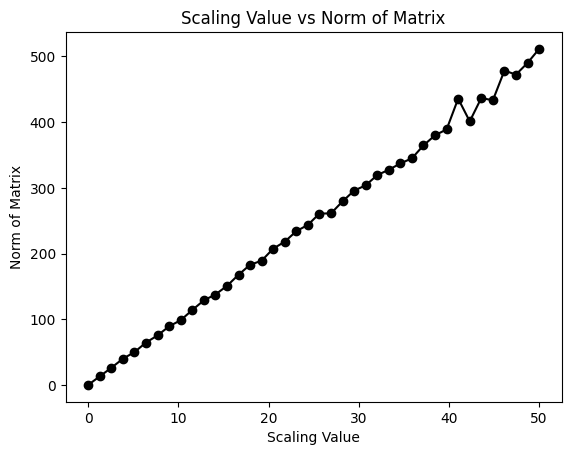

In [66]:
plt.plot(scaling_values,np.mean(norm_matrix,axis=1), "ko-")
plt.xlabel("Scaling Value")
plt.ylabel("Norm of Matrix")
plt.title("Scaling Value vs Norm of Matrix")


What we are seeing from this problem is that the norm of a matrix is related to the scale of the numerical values in the matrix. This makes sense given the norm of a matrix is the Euclidean distance from the origin. So if we had values in the matrix that are larger then the norm (distance) would be larger. This relationship is inherently linear given a scalar multiplier is a linear operation.

# Exercise 6-2
- Write an algorithm that finds a scalar that brings the Frobenius distance between two matrices to 1.
- Write a python function that takes 2 matrices of the same size and returns the Frobenius distance between them
- Then create 2 NxN random matrices.
- Create a variable `s = 1` that scalar multiplies both matrices
- As long as the distance remains above 1, set the scalar to be 0.9 itself and recompute the distance between the scaled matrices.

In [67]:
def frob_dist(A: np.ndarray, B: np.ndarray) -> np.float64:
    return np.linalg.norm(A - B)

In [68]:
size = 7
X, Y = np.random.randn(size, size), np.random.randn(size, size)
X, Y

(array([[ 1.22322061e-01,  2.21241731e-01, -1.56439248e+00,
          1.03595479e+00,  1.05120660e+00,  2.34937415e-01,
         -4.79759661e-01],
        [-1.08273670e+00,  1.17892031e+00, -1.86525420e+00,
          1.03541843e-01,  9.25815385e-01,  3.38016830e-01,
         -9.22289348e-01],
        [-5.31026275e-01,  4.22518897e-01,  5.65937910e-01,
         -1.56396560e+00, -6.96570042e-01, -1.65650109e+00,
         -6.96836066e-01],
        [-9.72376829e-01, -1.67148280e-01,  1.62082901e+00,
          4.76722755e-01, -3.68554737e-01,  1.38838503e+00,
          7.29536320e-01],
        [-1.42500129e+00,  2.57916345e-01, -1.87344296e-03,
         -9.06549875e-01, -6.57484282e-01, -1.01318712e+00,
          4.29431362e-01],
        [ 2.06563762e+00, -6.36112272e-01,  2.58301832e-01,
          8.65500989e-01, -9.66775546e-01,  9.22460964e-01,
          1.03664707e+00],
        [-8.59291734e-01,  4.76865704e-01,  4.28628130e-01,
         -9.59286379e-01,  3.34023913e-01,  1.62685721e+00

In [69]:
frob_dist(X, Y)

np.float64(8.945733668631906)

In [70]:
scalar = 1
count = 0
while (distance := frob_dist(X*scalar, Y*scalar)) > 1:
    scalar *= 0.9
    count += 1

In [71]:
distance, count

(np.float64(0.9788331350614393), 21)

# Exercise 6-3
- Demonstrate that the trace method and the Euclidean formula produce the same result
- Does the trace formular work only for $A^TA$ or is it the same for $AA^T$?
    - The trace is just the sum of the diagonals. In a transpose operation the diagonals would stay the same and so those are equivalent

In [72]:
trace_matrix = np.random.randn(size, size)
trace_matrix

array([[-0.62712452, -1.55208267, -0.56107737, -0.23127867, -0.04531395,
        -0.87847426, -1.02746503],
       [-1.13132828,  0.70459734, -0.46721012, -2.05652806, -0.15330081,
         0.12133146, -0.61909073],
       [-1.26605227,  0.03412392, -0.42293682,  0.3603752 , -1.50798644,
         2.85930101, -0.06259086],
       [ 0.72968455, -0.08093931, -0.32081946, -0.64903169, -1.47621032,
         1.24841459, -0.89002246],
       [ 0.66533751, -0.62907217,  0.32150099,  0.38502446, -1.69358244,
         0.18366419,  0.73875843],
       [ 1.24278662,  0.44443046,  1.06885318,  0.91711739, -1.0191918 ,
         0.39163573,  1.07966534],
       [ 0.89162051,  0.64037589,  0.18303925, -0.67460245,  0.15917814,
        -0.29464848, -0.76474847]])

In [73]:
trace_norm = np.linalg.norm(trace_matrix)
trace_based_norm = np.sqrt(np.trace(trace_matrix.T @ trace_matrix))
trace_norm, trace_based_norm

(np.float64(6.528139559771331), np.float64(6.528139559771331))

In [74]:
# as shown here AA^T == A^TA
np.sqrt(np.trace(trace_matrix @ trace_matrix.T))

np.float64(6.528139559771331)

# Exercise 6-4
- Exploring the impact of shifting a matrix on the norm of that matrix
- Create a 10x10 random matrix and compute it's Frobenius norm
- In a loop shift the matrix by a fraction of the norm
- compute the % change in norm from the original
- compute the Frobenius distance between the shifted and original matrix
- compute the correlation coefficient between the elements in the matrix (correlate the vectorized matrices using `np.flatten()`)
- The fraction of the norm that you shift by should range from 0 to 1 in 30 linearly spaced steps
- In each loop make sure you use the oringal matrix not the shifted

In [75]:
source_matrix = np.random.randn(10, 10)
source_norm = np.linalg.norm(source_matrix)
shift_count = 30
shift_vals = np.linspace(0,1,shift_count)
shift_results = np.zeros((3, shift_count))
for i, shift_val in enumerate(shift_vals):
    # needed (shift_val * source_norm) * identity matrix before adding back to the source matrix
    shifted_matrix = source_matrix + shift_val*source_norm*np.eye(10)
    shift_norm = np.linalg.norm(shifted_matrix, "fro")
    shift_results[0][i] = shift_norm / source_norm * 100
    shift_results[1][i] = np.linalg.norm(shifted_matrix - source_matrix, "fro")
    shift_results[2][i] = np.corrcoef(source_matrix.flatten(), shifted_matrix.flatten())[0, 1]

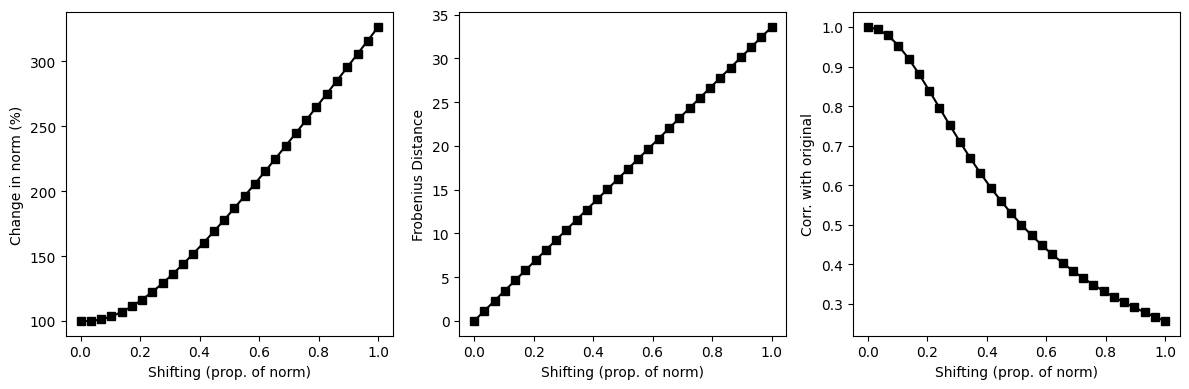

In [76]:
resultsNames = ["Change in norm (%)", "Frobenius Distance", "Corr. with original"]
_, axs = plt.subplots(1, 3, figsize=(12,4))
for i, title in enumerate(resultsNames):
    axs[i].plot(shift_vals, shift_results[i], "ks-")
    axs[i].set_xlabel("Shifting (prop. of norm)")
    axs[i].set_ylabel(title)
plt.tight_layout()

# Exercise 6-5
- How to create random matrix with arbitrary rank
- multiply a random $M \times r$ matrix with an $r \times N$ matrix

In [77]:
M = 5
N = 8
r = 3

A = np.random.randn(M,r) @ np.random.randn(r,N)
A.shape, np.linalg.matrix_rank(A)

((5, 8), np.int64(3))

This makes sense because $rank(AB) \le min(rank(A), rank(B))$. The min possible rank of either matrix is `r`. Since both matrices are random we will get a rank of `r` for both. Then we take advantage of the fact that $A_{M,r} \times B_{r,N}$ will be $C_{M,N}$

In [101]:
rank_A = np.diag([1,0,0])
rank_B = np.diag([-1,0,0])
C = rank_A + rank_B

In [102]:
np.linalg.matrix_rank(rank_A), np.linalg.matrix_rank(rank_B), np.linalg.matrix_rank(C)

(np.int64(1), np.int64(1), np.int64(0))

In [103]:
# two pairs with rank of 1
rank_B = np.zeros(rank_A.shape)
rank_B[0,1] = 10
C = rank_A + rank_B
np.linalg.matrix_rank(rank_A), np.linalg.matrix_rank(rank_B), np.linalg.matrix_rank(C)

(np.int64(1), np.int64(1), np.int64(1))

In [105]:
# two pairs with rank of 2
rank_A = np.diag([1,0,0])
rank_B = np.diag([0,1,0])
C = rank_A + rank_B
np.linalg.matrix_rank(rank_A), np.linalg.matrix_rank(rank_B), np.linalg.matrix_rank(C)

(np.int64(1), np.int64(1), np.int64(2))

# Exercise 6-7
- use code from 6-5 in a python function that takes parameters M and r as inputs and provides a random $M \times M$ rank-r matrix as output.
- in a double for loop create pairs of 20x20 matrices with individual ranks varying from 2 to 15
- add and multiply those matrices
- store the ranks of those resulting matrices
- those ranks can be organized into a matrix and visualized as a function fo the ranks of the individual matrices

In [108]:
def rank_matrix(M: int, r: int) -> np.array:
    x = np.random.randn(M, r)
    return x @ x.T

In [110]:
np.linalg.matrix_rank(rank_matrix(5, 2))

np.int64(2)

In [124]:
M_size = 20
ranks = range(2, 16)
rank_results = np.zeros((len(ranks), len(ranks), 2))
for i in range(len(ranks)):
    for j in range(len(ranks)):
        A = rank_matrix(M_size, i)
        B = rank_matrix(M_size, j)
        rank_results[i,j,0] = np.linalg.matrix_rank(A+B)
        rank_results[i,j,1] = np.linalg.matrix_rank(A@B)

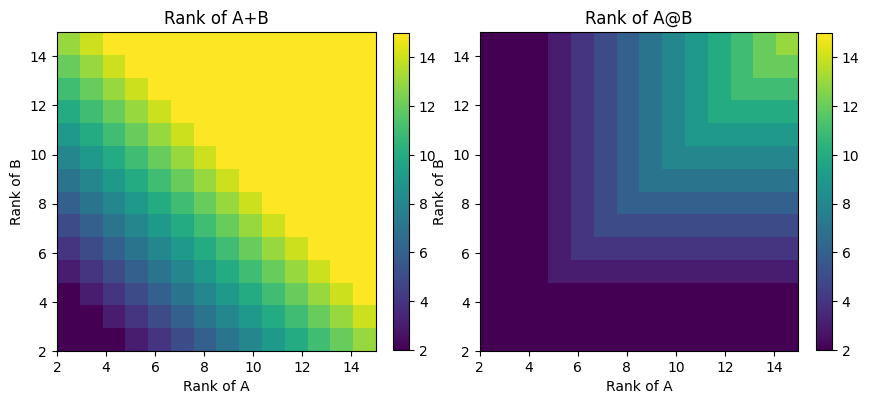

In [127]:
fig, axs = plt.subplots(1,2,figsize=(10,6))
s = '+@'

for i in range(2):

  # draw heatmap
  h = axs[i].imshow(rank_results[:,:,i],vmin=np.min(ranks),vmax=np.max(ranks),origin='lower',
                    extent=(ranks[0],ranks[-1],ranks[0],ranks[-1]))

  # add colorbar and other niceties
  fig.colorbar(h,ax=axs[i],fraction=.045)
  axs[i].set_xlabel('Rank of A')
  axs[i].set_ylabel('Rank of B')
  axs[i].set_title(f'Rank of A{s[i]}B')


Summing two matrices will increase the rank "faster" given $rank(A + B) \le rank(A) + rank(B)$ compared to multiplying matrices which are bound by the min rank of the two individual matrices.

# Exercise 6-9
- the goal is to answer $v \in C(A)$
- Create a rank-3 matrix $A \in \mathbb R^{4 \times 3}$ and vector $v \in \mathbb R^4$ using random numbers drawn from a normal distribution.
- Follow the earlier described algorithm to determine whether the vector is in the column space of the matrix
- Rerun the code multiple times to see whether or you find a consistent pattern.
- Next use a $A \in \mathbb R^{4 \times 4}$ rank-4 matrix. You should always find that $v \in C(A)$ when $A$ is a $4 \times 4$ random matrix (this is because the rank and column space is the same and thus no new information could be added via the vector)

In [138]:
A = rank_matrix(4, 3)
v = np.random.randn(4, 1)
A, v

(array([[ 0.61366207,  0.01689211,  0.32451228,  1.09295182],
        [ 0.01689211,  0.24908973, -0.08501299, -0.16600398],
        [ 0.32451228, -0.08501299,  1.47359292,  2.57659986],
        [ 1.09295182, -0.16600398,  2.57659986,  5.02573985]]),
 array([[ 0.0708531 ],
        [-0.84038109],
        [ 1.26975936],
        [-1.93474348]]))

In [139]:
A_rank = np.linalg.matrix_rank(A)
A_rank

np.int64(3)

In [140]:
np.linalg.matrix_rank(np.column_stack((A, v)))

np.int64(4)

In [141]:
B = rank_matrix(4, 4)
np.linalg.matrix_rank(B)

np.int64(4)

In [142]:
np.linalg.matrix_rank(np.column_stack((B, v)))

np.int64(4)

# Exercise 6-10
- The determinant of a reduce-rank matrix is in theory zero
- Create a square random matrix
- reduce the rank of the matrix (set on column to be the multiple of another)
- compute the determinant and store its absolute value
- run these three steps in a double for loop, one loop over matrix sizes ranging from 3 to 30 and a second loop repeates the three steps 100 times.
- Finally plot the determinant, averaged over 100 repeats
- Linear algebra theory predicts that the line is zero regardless of matrix size. Figure shows otherwise, reflecting the computational difficulties with acccurately computing the determinant. Plot on log and linear scale

In [150]:
square_matrix = np.random.randn(3,3)
square_matrix[:,0] = square_matrix[:,1] * 2
square_matrix

array([[-2.41946681, -1.2097334 ,  1.51244791],
       [ 1.10829218,  0.55414609,  1.71131508],
       [-1.4312017 , -0.71560085,  0.52147797]])

In [153]:
experiments = 100
matrix_sizes = np.arange(3, 31)

determinant_results = np.zeros((len(matrix_sizes), experiments))

for i, size in enumerate(matrix_sizes):
    for exp_i in range(experiments):
        square_matrix = np.random.randn(size, size)
        square_matrix[:,0] = square_matrix[:,1] * 2
        val = abs(np.linalg.det(square_matrix))
        determinant_results[i,exp_i] = val

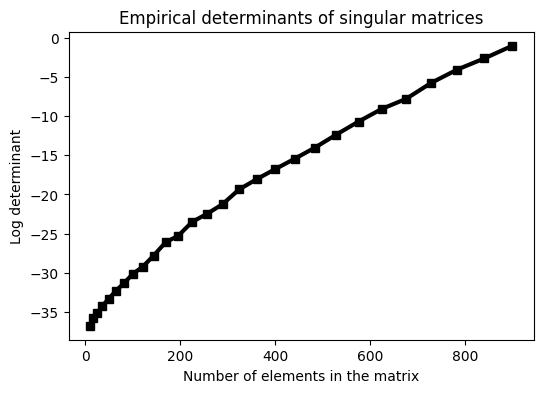

In [156]:
plt.figure(figsize=(6,4))
plt.plot(matrix_sizes**2,np.log(np.mean(determinant_results,axis=1)),'ks-',linewidth=3)
plt.xlabel('Number of elements in the matrix')
plt.ylabel('Log determinant')
plt.title('Empirical determinants of singular matrices')
plt.savefig('Figure_06_10.png',dpi=300)
plt.show()